In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

Dataset path or embeddings path is not set. Please check the .env configuration.


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: kaggle


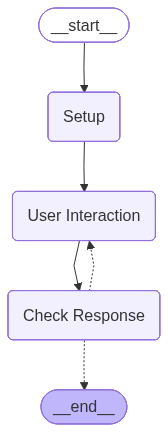

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [4]:
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    # Invoca a avaliação com as configurações estendidas
    eval_result = eval_graph.invoke({
        "experiment": experiment,
        "max_retries": 2,
        "debug_mode": True,
        "model_version": model_version,
        "experiment_type": experiment_type
    })

    print("Experimento avaliado:\n", eval_result["experiment_eval"])

    # Adiciona o resultado da avaliação junto com o ID do experimento e configuração
    evals.append({
        "experiment_id": exp_id,
        "experiment_config": eval_result.get("experiment_config", {
            "max_retries": 2,
            "model_version": model_version,
            "timestamp": datetime.now().isoformat(),
            "experiment_type": experiment_type
        }),
        "experiment_eval": eval_result["experiment_eval"]
    })

    # Atualiza o arquivo salvando o resultado atual
    with open(evals_filename, 'w', encoding='utf-8') as f:
        json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  Who are the players inducted into the hall of fame and their birth details?


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


[INFO] O resultado da execução foi: {
    "input": "Who are the players inducted into the hall of fame and their birth details?",
    "schema_linking": [
        "KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME",
        "KAGGLE.THEHISTORYOFBASEBALL_PLAYER"
    ],
    "answer": "There are 312 players inducted into the Hall of Fame. Some examples include Hank Aaron (born February 5, 1934, in Mobile, Alabama, USA), Roberto Alomar (born February 5, 1968, in Ponce, Puerto Rico), and Walter Alston (born December 1, 1911, in Venice, Ohio, USA). Let me know if you'd like more details or specific players.",
    "sql": "SELECT  p.name_first, p.name_last, p.birth_year, p.birth_month, p.birth_day, p.birth_country, p.birth_state, p.birth_city\nFROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME h\nJOIN KAGGLE.THEHISTORYOFBASEBALL_PLAYER p\nON h.player_id = p.player_id\nWHERE LOWER(h.inducted) = 'y';"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
Adj. True cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_COUNTRY', 'BIRTH_STATE', 'BIRTH_CITY'],
      dtype='object')
Adj. Predicted cols: Index(['NAME_FIRST', 'NAME_LAST', 'BIRTH_YEAR', 'BIRTH_MONTH', 'BIRTH_DAY',
       'BIRTH_CITY', 'BIRTH_STATE', 'BIRTH_COUNTRY'],
      dtype='object')
[INFO] A avaliação para esse turno foi:  {'interaction_id': 1, 'original_intent': 'Find the players inducted into the hall of fame and their birth details.', 'total_retries_needed': 0, 'success_without_retry': True, 'turns': [{'user_query': 'Who are the players inducted into the hall of fame and their birth details?', 'agent_r

...

[INFO] O resultado da execução foi: {
    "input": "Rank the inducted players who won the 'Cy Young' award by their points won.",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME", "THEHISTORYOFBASEBALL_PLAYER_AWARD_VOTE", "THEHISTORYOFBASEBALL_PLAYER"],
    "answer": "Here is the ranking of inducted players who won the 'Cy Young' award based on points won:\n\n1. Randy Johnson with 160 points.\n2. Randy Johnson again with 156 points.\n3. Pedro Martinez with 140 points.\n4. Greg Maddux with 140 points.\n\nThe list contains 137 records of players ranked by their points won.",
    "sql": "SELECT phof.player_id, p.name_first, p.name_last, pawv.points_won\nFROM kaggle.thehistoryofbaseball_hall_of_fame phof\nJOIN kaggle.thehistoryofbaseball_player_award_vote pawv ON phof.player_id = pawv.player_id\nJOIN kaggle.thehistoryofbaseball_player p ON phof.player_id = p.player_id\nWHERE phof.inducted = 'Y' AND LOWER(pawv.award_id) = LOWER('Cy Young')\nORDER BY pawv.points_won DESC"
}.

-----

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects a

[INFO] O resultado da execução foi: {
    "input": "Provide the salary and award year for inducted players.",
    "schema_linking": ["THEHISTORYOFBASEBALL_HALL_OF_FAME", "THEHISTORYOFBASEBALL_SALARY", "THEHISTORYOFBASEBALL_PLAYER_AWARD"],
    "answer": "There are 7,826 records of salary and award year data for inducted players. For example:\n\n1. A player earned $1,354,167 in 1981.\n2. Another player earned $5,500,000 in 2007.\n\nThe data shows both salary and award years for various players.",
    "sql": "SELECT  s.salary, a.year \nFROM KAGGLE.THEHISTORYOFBASEBALL_HALL_OF_FAME h\nJOIN KAGGLE.THEHISTORYOFBASEBALL_SALARY s\n  ON h.player_id = s.player_id\nJOIN KAGGLE.THEHISTORYOFBASEBALL_PLAYER_AWARD a\n  ON h.player_id = a.player_id\nWHERE LOWER(h.inducted) = 'y'"
}.

----------------------------------------
[NODE] Check Response Node entered.
[INFO] O resultado da execução foi: {
    "input": "Provide the salary and award year for inducted players.",
    "schema_linking": ["THEHISTORY

/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


True cols: Index(['PLAYER_ID', 'SALARY', 'YEAR'], dtype='object')
Adj. True cols: Index([], dtype='object')
Predicted cols: Index(['SALARY', 'YEAR'], dtype='object')
Adj. Predicted cols: Index([], dtype='object')
[AI as JUDGE sql query correctness] Result: F with 0.9999850252454783 of confidence. And result metadata: {'token_usage': {'completion_tokens': 2, 'prompt_tokens': 604, 'total_tokens': 606, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_b54fe76834', 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs